# Validate fire products against ground-truth references

This notebook is the **accuracy** companion to `run_fire_comparison.ipynb`. That
notebook asks *"do the products agree with each other?"* (no truth). This one asks
*"is a product **right**?"* — it scores each remotely-sensed product against
independent reference fire perimeters (NIFC large fires, TNC preserve burns,
NCWRC prescribed fires) curated with Margaret's help.

**What the metrics mean (read this first):**
- **recall = 1 − omission** is the headline number: of a known fire's footprint,
  the fraction the product detected. Clean, because a fire definitely occurred
  inside the perimeter.
- **precision** is reported only *per event, inside a buffered window*, and is
  **conditional**: the references are not a complete census (a product burn
  outside them may be a real small fire, not a false alarm), and a perimeter is
  an *outer boundary* that includes unburned islands (it overestimates truth).
- Scoring is **time-matched, per event** — each incident vs the product layer for
  its own year. Active fire (VIIRS) is judged at the event level (`detected`),
  and is 2012+ so it is simply absent for the older fires.

See `decisions.md` → *Ground-truth validation toolkit* for the full rationale.

## 0. Setup & AOI

In [ ]:
%load_ext autoreload
%autoreload 2

import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from peatfire import data_path
from peatfire.fire_products_comparison import (
    list_references, get_reference, load_reference, reference_event_table,
    validate_event, validate_products, summarize_validation, recall_matrix,
    confusion_scores, rasterize_polygons_to_grid, build_common_grid,
    stack_on_common_grid, list_products,
    set_fire_style, plot_validation_heatmap,
    plot_reference_vs_product_for_one_event,
)

set_fire_style()

# Same AOI swap-in as the comparison notebook: NC / peatlands / coastal plain all work.
aoi = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))

## 1. What references are registered, and what's on disk?

Each reference is a vector source of fire perimeters. A source whose folder is
missing skips with a warning (like the products), so this runs on whatever you've
downloaded. Expected processed layout (clip the raw NIFC gpkgs in
`download_and_clip_data.ipynb` first):

```
data/processed/fire/reference/nifc_ifph/nifc_ifph_*.gpkg   # default NIFC source
data/processed/fire/reference/geomac/geomac_*.gpkg         # 2000-2018 cross-check
data/processed/fire/reference/tnc_burns/tnc_burns_*.shp
```

In [4]:
rows = []
for name in list_references():
    s = get_reference(name)
    n = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"reference": name, "kind": s.kind, "dir_exists": s.directory.exists(),
                 "n_files": n, "directory": str(s.directory)})
pd.DataFrame(rows).set_index("reference")

,kind,dir_exists,n_files,directory
reference,,,,
NIFC_IFPH,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
GEOMAC,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_SANDHILLS,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_COASTAL_PLAIN,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
NCWRC_RX,perimeter,False,0,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. The event menu

`reference_event_table` lists every incident in the source within the AOI — your
menu of fires to validate against, and where to find Margaret's named events
(Evans Road 2008, Pains Bay 2011, Juniper Road 2011, Whipping Creek 2016,
Great Lakes 2023, ...).

In [17]:
events

,source,event,year,month,acres
0,NIFC_IFPH,BOCK QUARR,1942.0,1.0,14.833572
1,NIFC_IFPH,DEVILS,1942.0,1.0,2.603379
2,NIFC_IFPH,FOX BRANCH,1942.0,1.0,97.502312
3,NIFC_IFPH,LAMBERT,1942.0,1.0,1.138890
4,NIFC_IFPH,MT STERLIN,1942.0,1.0,619.395996
...,...,...,...,...,...
417,NIFC_IFPH,OLD ROUGHY,2024.0,11.0,179.000000
418,NIFC_IFPH,OYSTER POINT,2024.0,1.0,0.110000
419,NIFC_IFPH,POISON FORK,2024.0,1.0,58.580002
420,NIFC_IFPH,RAILROAD,2024.0,1.0,38.330002


## 3. Validate one event in detail

`validate_event` takes one perimeter row, builds a buffered analysis-window grid
around it, rasterises the perimeter to the "reference burned" mask, loads every
product on that same grid for the event's year, and returns per-product
recall / precision / detected. Pick a Margaret fire by name.

In [8]:
products = list_products("burned_area")
products

['MCD64A1', 'GABAM', 'FireCCI51', 'FireCCIS311', 'USGS_BA']

In [9]:
ref = load_reference("NIFC_IFPH", aoi)
if ref is not None:
    # pick one event by name substring (case-insensitive); fall back to the first row
    hit = ref[ref["_event"].str.contains("Evans Road", case=False, na=False)]
    event_gdf = hit if len(hit) else ref.iloc[[0]]
    year = int(event_gdf["_year"].iloc[0])
    print("event:", event_gdf["_event"].iloc[0], "| year:", year)
    detail_one = validate_event(
        event_gdf,
        products=list_products("burned_area") + list_products("occurrence"),
        year=year, buffer_km=5.0,
    )
    display(detail_one[["event", "year", "product", "family",
                        "recall", "precision", "detected", "n_ref", "n_prod"]])
else:
    print("NIFC_IFPH not downloaded yet — skipping.")

event: JOE BROWN | year: 2023


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/fire_products_comparison/fire_products.py:452: UserWarning: USGS_BA: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/fire/usgs_lba does not exist -- skipping.
  files = _files_for_period(spec, year, month)


,event,year,product,family,recall,precision,detected,n_ref,n_prod
0,JOE BROWN,2023,MCD64A1,burned_area,0.0,NaN,False,3,0
1,JOE BROWN,2023,FireCCIS311,burned_area,0.0,NaN,False,3,0


## 4. Validate across all events of a source

`validate_products` runs every event of a reference, time-matched, and returns one
tidy row per (event, product). `min_acres` focuses on mappable incidents;
`match="month"` tightens timing when the source carries dates.

In [ ]:
detail = validate_products(
    "NIFC_IFPH", aoi,
    products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"],
    buffer_km=5.0, min_acres=100.0, match="year",
)
detail.head(20) if not detail.empty else "no events scored (source not downloaded?)"

,source,event,year,month,product,family,tp,fn,fp,n_ref,n_prod,recall,precision,detected
0,NIFC_IFPH,COLLETT RIDGE,2023,None,MCD64A1,burned_area,96,31,65,127,161,0.755906,0.596273,True
1,NIFC_IFPH,COLLETT RIDGE,2023,None,FireCCIS311,burned_area,0,127,23,127,23,0.000000,0.000000,False
2,NIFC_IFPH,COLLETT RIDGE,2023,None,VIIRS,occurrence,55,72,12,127,67,0.433071,0.820896,True
3,NIFC_IFPH,OLD ROUGHY,2024,None,MCD64A1,burned_area,0,10,0,10,0,0.000000,NaN,False
4,NIFC_IFPH,OLD ROUGHY,2024,None,FireCCIS311,burned_area,0,10,0,10,0,0.000000,NaN,False
5,NIFC_IFPH,Gladys Branch,2016,None,MCD64A1,burned_area,0,11,0,11,0,0.000000,NaN,False
6,NIFC_IFPH,Gladys Branch,2016,None,GABAM,burned_area,0,11,0,11,0,0.000000,NaN,False
7,NIFC_IFPH,Gladys Branch,2016,None,FireCCI51,burned_area,0,11,0,11,0,0.000000,NaN,False
8,NIFC_IFPH,Gladys Branch,2016,None,VIIRS,occurrence,2,9,0,11,2,0.181818,1.000000,True
9,NIFC_IFPH,TUNNEL,2001,None,MCD64A1,burned_area,0,27,0,27,0,0.000000,NaN,False


## 5. Per-product roll-up

`recall_pooled` is cell-weighted (dominated by the big fires — "what fraction of
burned *area* was caught?"). `recall_mean_event` weights each fire equally
(surfaces small-fire omission). `detection_rate` = fraction of fires the product
saw at all. The precision column is the conditional within-window number.

In [26]:
if not detail.empty:
    display(summarize_validation(detail).round(3))

,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCI51,36,0.528,0.120,0.167,0.413
MCD64A1,59,0.513,0.132,0.203,0.418
FireCCIS311,31,0.497,0.193,0.387,0.424
GABAM,45,0.339,0.097,0.267,0.427
VIIRS,38,0.270,0.200,0.816,0.569


## 6. Events × products recall heatmap

Each row is one reference fire, each column a product — so per-incident strengths
and weaknesses read straight off. (e.g. does any product miss the escaped-Rx Dad
Fire, which only shows a remote signal for ~a year?)

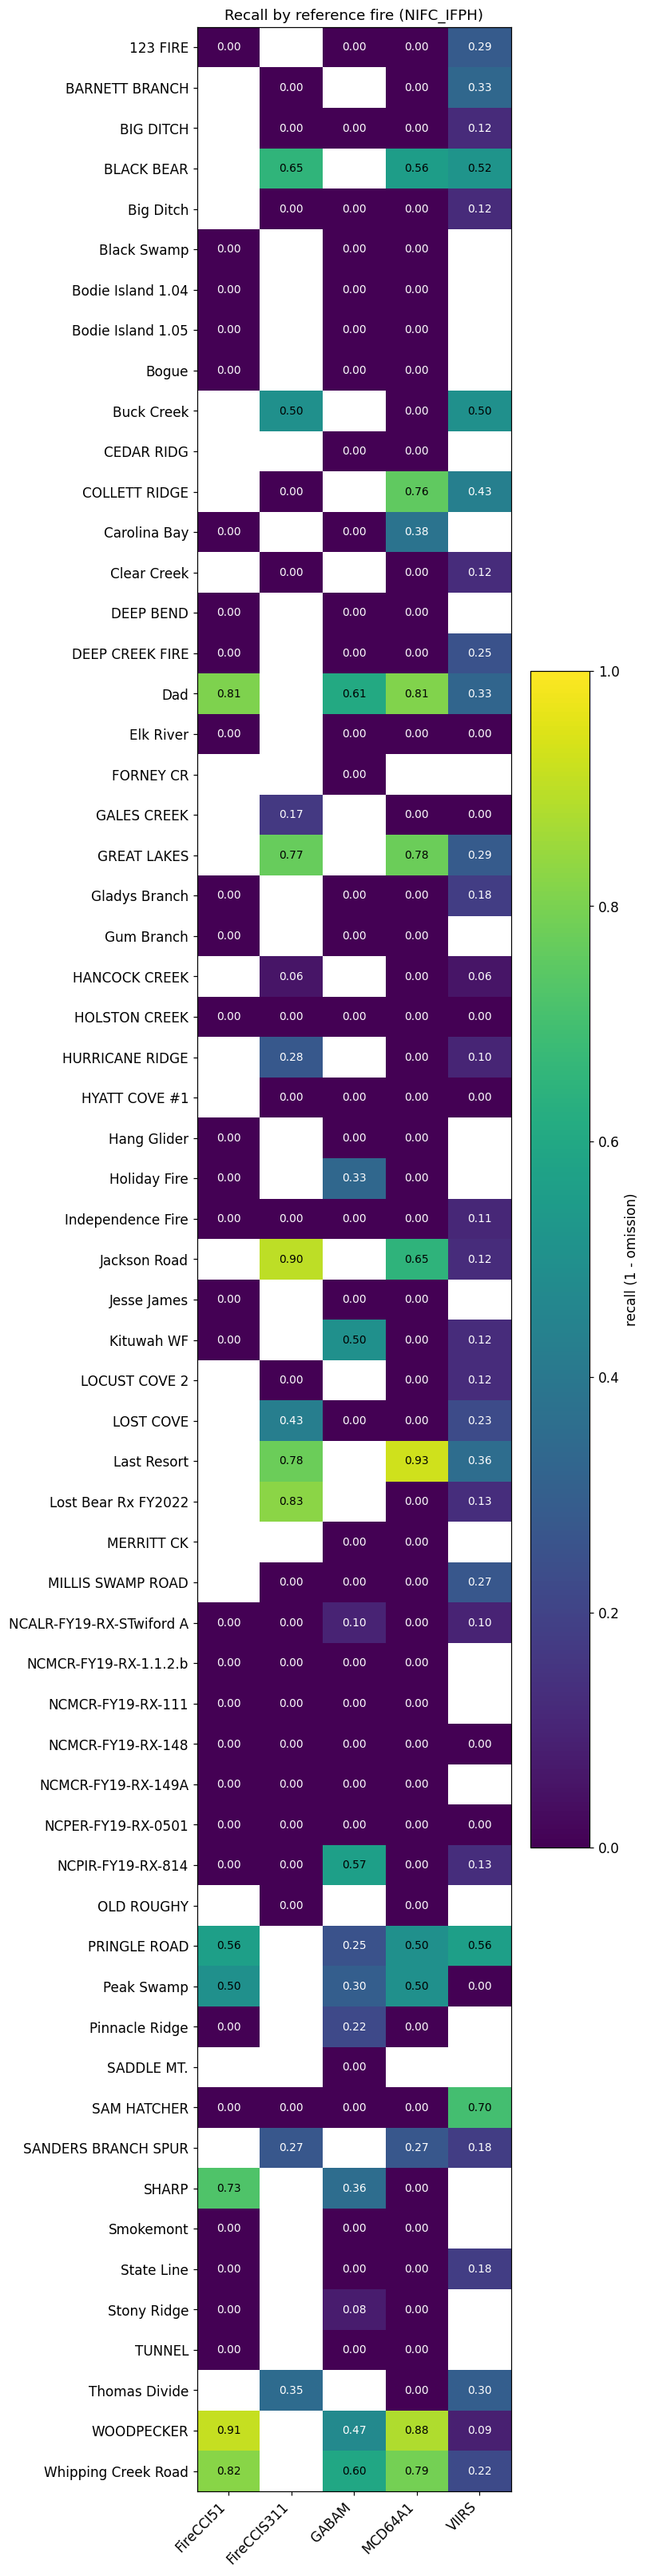

In [27]:
if not detail.empty:
    m = recall_matrix(detail, value="recall")
    plot_validation_heatmap(m, title="Recall by reference fire (NIFC_IFPH)")
    plt.savefig("../outputs/figures/fire/validation_recall_nifc_ifph.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 7. Small-fire references (TNC / NCWRC)

TNC preserve burns and NCWRC prescribed fires are *small* — a stress test of the
small-fire omission that coarse products (MCD64A1 500 m) are expected to fail.
Compare `recall_mean_event` here against the big-fire NIFC table above.

In [28]:
for src in ["TNC_SANDHILLS", "TNC_COASTAL_PLAIN", "NCWRC_RX"]:
    d = validate_products(src, aoi, products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311"])
    if d.empty:
        print(f"{src}: not downloaded — skipping"); continue
    print(f"=== {src} ===")
    display(summarize_validation(d).round(3))

=== TNC_SANDHILLS ===


,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCIS311,124,0.290,0.280,0.484,0.068
GABAM,348,0.118,0.113,0.259,0.110
FireCCI51,329,0.051,0.045,0.070,0.037
MCD64A1,441,0.026,0.025,0.075,0.065


KeyboardInterrupt: 

## 8. GeoMAC cross-check (do NOT pool with NIFC_IFPH)

GeoMAC (2000-2018) overlaps NIFC_IFPH, so the *same* fire is in both — pooling
double-counts. Run it separately as an independent cross-check on those years.

In [ ]:
d_geomac = validate_products("GEOMAC", aoi,
                             products=["MCD64A1", "GABAM", "FireCCI51"],
                             years=range(2000, 2019), min_acres=100.0)
if not d_geomac.empty:
    display(summarize_validation(d_geomac).round(3))

## 9. Note on severity

Perimeters carry **no severity** and we have no field CBI, so severity products
(SE FireMap, MOSEV, MTBS) are *not* scored here. Their proper validation use is to
**restrict the severity cross-comparison to reference cells** — i.e. compare them
only where a fire is known to have burned. Do that in `run_fire_comparison.ipynb`
by intersecting the severity stack with a rasterised reference mask
(`rasterize_polygons_to_grid`).

In [ ]:
import geopandas as gpd
from peatfire import data_path

for f in [data_path('raw', 'fire', 'reference', 'TNC_NC_Sandhills_Fire_History_2025', 'TNC_NC_Sandhills_Fire_History_2025.shp'),
          data_path('raw', 'fire', 'reference', 'TNC_NC_Sandhills_Fire_History_2025', 'TNC_NC_Coastal_Plain_Fire_History_2025.shp')]:
    
    g = gpd.read_file(f, rows=1)
    print(g.crs, list(g.columns))

EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'FIRE_TREAT', 'END_DATE', 'COMMENTS', 'YEAR', 'COUNTY', 'RESTORATIO', 'MONTH', 'Shape__Len', 'Shape__Are', 'geometry']
EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'COUNTY', 'FIRE_TREAT', 'Year', 'COMMENTS', 'END_DATE', 'RESTORATIO', 'Shape__Len', 'Shape__Are', 'geometry']
